# Imports

In [9]:
import pandas as pd
import numpy as np
import joblib
import os
from dotenv import load_dotenv
from openai import OpenAI
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Loads

In [2]:
load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

best_xgb = joblib.load('../models/tuned_xgboost.pkl')

holdout_clean = pd.read_csv('../data/df_working_clean.csv').tail(18052).reset_index(drop=True)

print("All loaded successfully!")
print(f"Holdout size: {holdout_clean.shape}")

All loaded successfully!
Holdout size: (18052, 38)


In [3]:
df_raw = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin-1')
df_raw['order date (DateOrders)'] = pd.to_datetime(df_raw['order date (DateOrders)'])
df_raw = df_raw.sort_values('order date (DateOrders)').reset_index(drop=True)
holdout_raw = df_raw.tail(18052).reset_index(drop=True)

print(f"Raw holdout size: {holdout_raw.shape}")

Raw holdout size: (18052, 53)


In [4]:
X_holdout = holdout_clean.drop(columns=['Late_delivery_risk'])
y_holdout = holdout_clean['Late_delivery_risk']

# Predict
holdout_probs = best_xgb.predict_proba(X_holdout)[:, 1]
holdout_preds = best_xgb.predict(X_holdout)

# Add predictions to raw holdout for context
holdout_raw['predicted_risk'] = holdout_preds
holdout_raw['risk_probability'] = holdout_probs

# Filter high risk orders
high_risk = holdout_raw[holdout_raw['predicted_risk'] == 1].sort_values(
    'risk_probability', ascending=False
)

print(f"High risk orders in holdout: {len(high_risk)}")
print(f"\nTop 5 highest risk orders:")
high_risk[['Order Region', 'Shipping Mode', 'Days for shipment (scheduled)', 
           'Product Name', 'risk_probability']].head()

High risk orders in holdout: 9691

Top 5 highest risk orders:


,Order Region,Shipping Mode,Days for shipment (scheduled),Product Name,risk_probability
16541,South Asia,Standard Class,4,Adult dog supplies,1.0
13305,South Asia,Standard Class,4,Men's gala suit,1.0
14633,Eastern Asia,Standard Class,4,Summer dresses,1.0
14630,Oceania,Second Class,2,Summer dresses,1.0
10211,Northern Europe,First Class,1,CDs of rock,1.0


# GenAI recovery action generator

In [5]:
def generate_recovery_action(order_row):
    """Generate a proactive recovery action for a high-risk order using LLM."""
    
    prompt = f"""
You are a supply chain operations assistant. An order has been flagged as HIGH RISK for late delivery.

ORDER DETAILS:
- Product: {order_row.get('Product Name', 'N/A')}
- Customer Segment: {order_row.get('Customer Segment', 'N/A')}
- Shipping Mode: {order_row.get('Shipping Mode', 'N/A')}
- Scheduled Delivery Days: {order_row.get('Days for shipment (scheduled)', 'N/A')}
- Order Region: {order_row.get('Order Region', 'N/A')}
- Market: {order_row.get('Market', 'N/A')}
- Late Delivery Probability: {order_row.get('risk_probability', 0):.1%}

Generate a concise proactive recovery plan that includes:
1. A short customer apology message (2-3 sentences, professional tone)
2. Two specific operational actions the supply chain team should take immediately
3. A recommended shipping upgrade if applicable

Keep the total response under 150 words and be specific to the order context.
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
        temperature=0.7
    )
    
    return response.choices[0].message.content

In [7]:
# Test on top 3 highest risk orders
print("=== PROACTIVE RECOVERY ACTIONS ===\n")

for i, (idx, order) in enumerate(high_risk.head(3).iterrows()):
    print(f"--- Order #{i+1} ---")
    print(f"Product: {order['Product Name']} | Region: {order['Order Region']} | Risk: {order['risk_probability']:.1%}")
    print("\nRecovery Action:")
    print(generate_recovery_action(order))
    print("\n" + "="*60 + "\n")

=== PROACTIVE RECOVERY ACTIONS ===

--- Order #1 ---
Product: Adult dog supplies | Region: South Asia | Risk: 100.0%

Recovery Action:
**Customer Apology Message:**
Dear [Customer's Name], we sincerely apologize for the potential delay in delivering your order for adult dog supplies. We understand the importance of timely deliveries and are actively working to resolve this issue.

**Operational Actions:**
1. Contact the shipping provider to expedite the processing of the order and confirm the current status of the shipment.
2. Review inventory levels and prioritize the fulfillment of this order to ensure it is ready for immediate dispatch once shipping arrangements are secured.

**Recommended Shipping Upgrade:**
To mitigate delays, we recommend upgrading the shipping mode from Standard Class to Express Shipping to ensure prompt delivery to the South Asia region.


--- Order #2 ---
Product: Men's gala suit | Region: South Asia | Risk: 100.0%

Recovery Action:
**Customer Apology Message:

# Holdout data evaluation

In [14]:
# Load and preprocess holdout properly
holdout_data = pd.read_csv('../data/holdout_raw.csv')

# Convert date and extract features
holdout_data['order date (DateOrders)'] = pd.to_datetime(holdout_data['order date (DateOrders)'])
holdout_data['order_month'] = holdout_data['order date (DateOrders)'].dt.month
holdout_data['order_dayofweek'] = holdout_data['order date (DateOrders)'].dt.dayofweek
holdout_data['order_quarter'] = holdout_data['order date (DateOrders)'].dt.quarter
holdout_data['order_year'] = holdout_data['order date (DateOrders)'].dt.year
holdout_data['order_hour'] = holdout_data['order date (DateOrders)'].dt.hour

# Drop same columns as working set
all_drops = [
    'Customer Email', 'Product Image', 'Product Status', 'Order Zipcode', 'Product Description',
    'Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)', 'Order Status',
    'Benefit per order', 'Order Profit Per Order', 'Customer Password', 'Customer Fname', 
    'Customer Lname', 'Customer Street', 'Order Id', 'Order Item Id', 'Order Customer Id',
    'Order Item Total', 'Sales per customer', 'Order Item Product Price', 'Order Item Discount',
    'Category Id', 'Product Category Id', 'Department Id', 'Order Item Cardprod Id',
    'Order Item Profit Ratio', 'Customer Zipcode', 'Product Card Id', 'Customer Id',
    'Order City', 'Order State', 'Customer City', 'Customer State', 'Order Country', 
    'Customer Country', 'order date (DateOrders)'
]
holdout_data = holdout_data.drop(columns=all_drops)

# One-Hot Encode
ohe_cols = ['Type', 'Customer Segment', 'Department Name', 'Market', 'Shipping Mode']
holdout_data = pd.get_dummies(holdout_data, columns=ohe_cols, drop_first=False)

# Label Encode using saved encoders from training
label_encoders = joblib.load('../models/label_encoders.pkl')

for col in ['Category Name', 'Order Region', 'Product Name']:
    le = label_encoders[col]
    known_labels = set(le.classes_)
    
    # Replace unseen labels with the most frequent known label
    holdout_data[col] = holdout_data[col].apply(
        lambda x: x if x in known_labels else le.classes_[0]
    )
    
    holdout_data[col] = le.transform(holdout_data[col])

# Convert bools to int
bool_cols = holdout_data.select_dtypes(include='bool').columns
holdout_data[bool_cols] = holdout_data[bool_cols].astype(int)

# Align columns with training set
X_train_cols = best_xgb.get_booster().feature_names
holdout_data = holdout_data.reindex(columns=X_train_cols + ['Late_delivery_risk'], fill_value=0)

X_holdout = holdout_data.drop(columns=['Late_delivery_risk'])
y_holdout = holdout_data['Late_delivery_risk']

print(f"Holdout shape: {holdout_data.shape}")
print(f"Missing values: {holdout_data.isnull().sum().sum()}")

Holdout shape: (18052, 38)
Missing values: 0


=== FINAL HOLDOUT EVALUATION ===

              precision    recall  f1-score   support

           0       0.63      0.67      0.65      8086
           1       0.72      0.68      0.70      9966

    accuracy                           0.68     18052
   macro avg       0.68      0.68      0.68     18052
weighted avg       0.68      0.68      0.68     18052

ROC-AUC Score: 0.7519


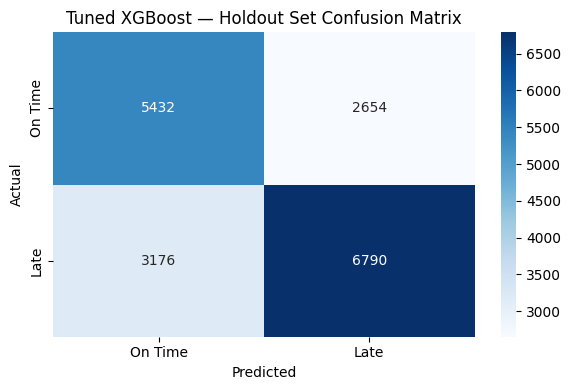

In [15]:
# Predict
y_pred_holdout = best_xgb.predict(X_holdout)
y_prob_holdout = best_xgb.predict_proba(X_holdout)[:, 1]

# Evaluate
print("=== FINAL HOLDOUT EVALUATION ===\n")
print(classification_report(y_holdout, y_pred_holdout))
print(f"ROC-AUC Score: {roc_auc_score(y_holdout, y_prob_holdout):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_holdout, y_pred_holdout),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['On Time', 'Late'],
    yticklabels=['On Time', 'Late'],
    ax=ax
)
ax.set_title('Tuned XGBoost — Holdout Set Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()